In [1]:
# =====================================================================
# CELL 1: Imports and Environment Setup
# Purpose: Load external libraries and your custom airfoil modules.
# =====================================================================

import numpy as np
from camber import camber_line, camber_slope
from Fourier import compute_fourier
from vector_field import mesh_generation, velocity_field
from circulation import circulation
from plots import plot_camber, plot_slope, plot_vector, plot_gamma_distribution, plot_novel_cambers

# Note: user_input is no longer imported here because it is defined in Cell 2.

In [2]:
# =====================================================================
# CELL 2: Interactive User Input 
# Purpose: Interactively collects airfoil geometry and flight parameters.
# =====================================================================

"""
Function: get_user_input
Description: Interactively collects airfoil geometry and flight parameters.
Inputs: None (User keyboard input).
Outputs: 
    - choice: Int (1: Custom, 2: NACA, 3: Novel Comparison).
    - m: Float (Max camber height).
    - p: Float (Max camber position).
    - alpha: Float or List (Angle of attack in degrees).
    - U: Float (Freestream velocity).
    - N: Int (Points for discretization).
Assumptions: User provides numeric values within realistic aerodynamic ranges.
"""
def get_user_input():
    # Selection menu for airfoil type 
    print("Select Camber Type")
    print("1 -> Custom Camber")
    print("2 -> NACA Camber")
    print("3 -> Novel Airfoil Comparison (Section 4 Tasks)")

    choice = int(input("Enter choice: ")) # User's selection code

    # Input handling for NACA geometry parameters 
    if choice != 1:
        m = float(input("Enter maximum camber, M [m]: ")) # Height of max camber 
        p = float(input("Enter maximum camber position, P [m]: ")) # Position of max camber 
    else:
        # Default placeholders for custom airfoil
        m = 0
        p = 0

    # Flight condition inputs 
    alpha = 0.0 # Initializing AoA variable
    if choice != 3:
        alpha = float(input("Enter angle of attack, \u03B1 [°]: ")) # Single AoA for standard runs
    
    U = float(input("Enter freestream velocity, U [m/s]: ")) # Airspeed magnitude (e.g., 20 m/s)
    N = 1000 # Number of discrete points along the chord length

    return choice, m, p, alpha, U, N

In [3]:
# =====================================================================
# CELL 2: Interactive User Input 
# Purpose: Interactively collects airfoil geometry and flight parameters.
# =====================================================================

"""
Function: get_user_input
Description: Interactively collects airfoil geometry and flight parameters.
             Automatically parses 4-digit NACA strings into m and p values.
Inputs: None (User keyboard input).
Outputs: 
    - choice: Int (1: Custom, 2: NACA, 3: Novel Comparison).
    - m: Float (Max camber height).
    - p: Float (Max camber position).
    - alpha: Float or List (Angle of attack in degrees).
    - U: Float (Freestream velocity).
    - N: Int (Points for discretization).
"""
def get_user_input():
    # Selection menu for airfoil type 
    print("Select Camber Type")
    print("1 -> Custom Camber")
    print("2 -> NACA Camber (4-digit)")
    print("3 -> Novel Airfoil Comparison (Section 4 Tasks)")

    choice = int(input("Enter choice: ")) # User's selection code

    # Default placeholders
    m = 0.0
    p = 0.0

    # Input handling for NACA geometry parameters 
    if choice == 2:
        naca_code = input("Enter 4-digit NACA number (e.g., 2412): ").strip()
        if len(naca_code) == 4 and naca_code.isdigit():
            # First digit is max camber in percent of chord (m)
            m = int(naca_code[0]) / 100.0
            # Second digit is position of max camber in tenths of chord (p)
            p = int(naca_code[1]) / 10.0
            print(f"Parsed NACA {naca_code}: Max Camber (m)={m}, Position (p)={p}")
        else:
            print("Invalid NACA format. Defaulting to m=0, p=0.")
            
    elif choice == 3:
        # For Novel comparison, m and p are usually used for the reference NACA airfoil
        m = float(input("Enter reference NACA max camber, M [m]: "))
        p = float(input("Enter reference NACA max camber position, P [m]: "))

    # Flight condition inputs 
    alpha = 0.0 
    if choice != 3:
        alpha = float(input("Enter angle of attack, \u03B1 [°]: "))
    
    U = float(input("Enter freestream velocity, U [m/s]: "))
    N = 1000 # Number of discrete points

    return choice, m, p, alpha, U, N

Select Camber Type
1 -> Custom Camber
2 -> NACA Camber (4-digit)
3 -> Novel Airfoil Comparison (Section 4 Tasks)
Parsed NACA 2212: Max Camber (m)=0.02, Position (p)=0.2


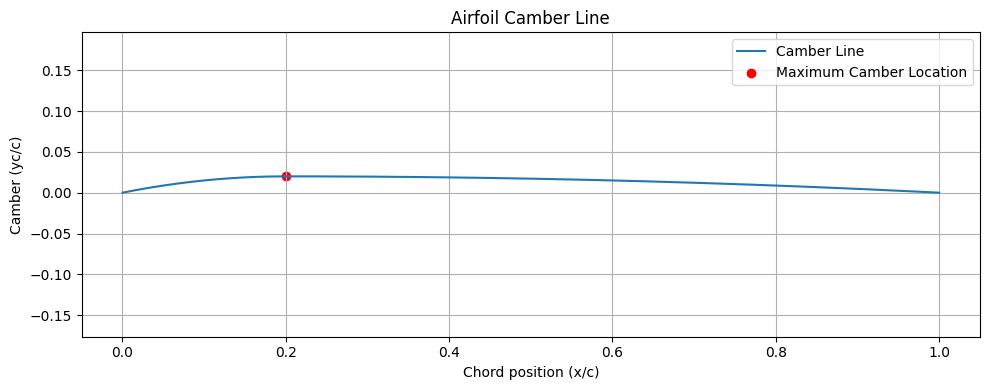

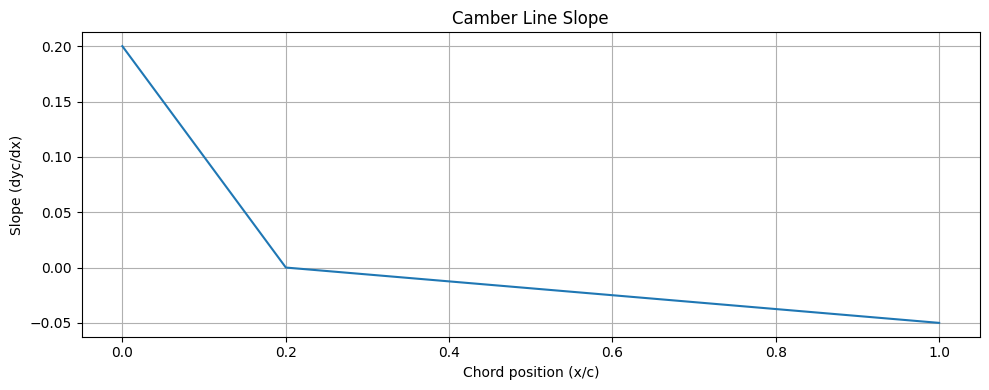

In [4]:
# =====================================================================
# CELL 3A: Geometry Generation and Plotting
# =====================================================================

# 1. Execute User Input (Ensure Cell 2 was run)
choice, m, p, alpha, U, N = get_user_input()

# 2. Generate Coordinates
if choice == 3:
    x, yc, theta, yc1, yc2, yc3 = camber_line(choice, m, p, N)
    # Plot Comparison Graph
    plot_novel_cambers(x, yc, yc1, yc2, yc3)
else:
    x, yc, theta = camber_line(choice, m, p, N)
    slope = camber_slope(choice, m, p, x)
    # Plot Individual Geometry Graphs
    plot_camber(x, yc, m, p)
    plot_slope(x, slope, p)



In [5]:
# =====================================================================
# CELL 3B: Aerodynamic Coefficient Analysis
# =====================================================================

if choice == 3:
    alpha_list = [-3, 0, 3, 6, 9, 12]
    s1, s2, s3 = camber_slope(choice, m, p, x)
    s_ref = camber_slope(2, m, p, x)
    
    # We will store these for the next cell
    all_slopes = [s_ref, s1, s2, s3]
    all_yc = [yc, yc1, yc2, yc3]
    
    for j in range(4):
        print(f"\n--- Aerodynamic Results for Airfoil {j} ---")
        current_slope = all_slopes[j]
        for a in alpha_list:
            A0, A1, A2, Cl, Cm = compute_fourier(a, theta, current_slope)
            print(f"AoA: {a}° -> Cl: {Cl:.4f}, Cm: {Cm:.4f}")
else:
    # Standard Analysis
    A0, A1, A2, Cl, Cm = compute_fourier(alpha, theta, slope)
    print(f"\n--- Aerodynamic Results ---")
    print(f"A0: {A0:.4f}, A1: {A1:.4f}, A2: {A2:.4f}")
    print(f"Lift Coefficient (Cl): {Cl:.4f}")
    print(f"Moment Coefficient (Cm_c/4): {Cm:.4f}")




--- Aerodynamic Results ---
A0: 0.0697, A1: 0.0980, A2: 0.0509
Lift Coefficient (Cl): 0.7456
Moment Coefficient (Cm_c/4): -0.0739


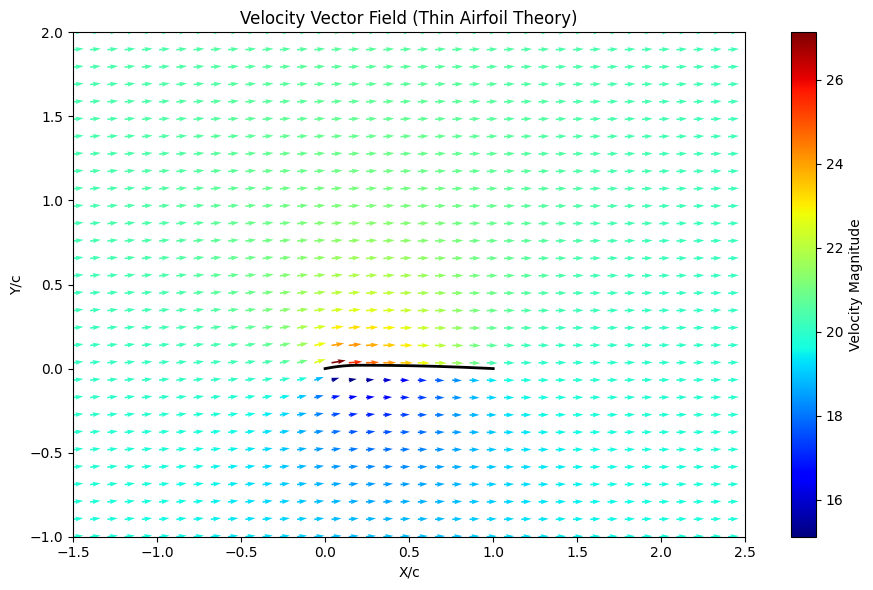

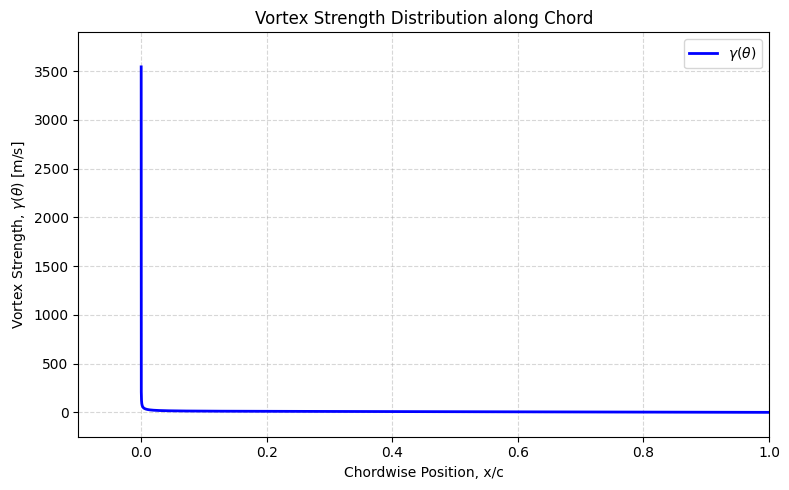


Total Circulation (Integrated): 7.4557
Total Circulation (Line Integral): 7.4353


In [6]:
# =====================================================================
# CELL 3C: Flow Field and Circulation Plotting
# =====================================================================

xg, yg = mesh_generation()

if choice == 3:
    # Plotting Vector Fields for Novel Airfoils at a fixed AoA (3 degrees)
    target_aoa = 3
    for j in range(1, 4): # Plotting Airfoils 1, 2, and 3
        A0, A1, A2, Cl, Cm = compute_fourier(target_aoa, theta, all_slopes[j])
        u, v, Vm, _, _ = velocity_field(xg, yg, theta, A0, A1, A2, U, target_aoa)
        plot_vector(xg, yg, u, v, Vm, x, all_yc[j], l=f"Velocity Vector Field: Airfoil {j}")
else:
    # Plotting Vector Field and Gamma for Single Airfoil
    u, v, Vm, gamma, x_v = velocity_field(xg, yg, theta, A0, A1, A2, U, alpha)
    plot_vector(xg, yg, u, v, Vm, x, yc)
    plot_gamma_distribution(x_v, gamma)

    # Circulation Verification
    dx_v = np.diff(0.5 * (1 - np.cos(theta)))
    Gamma_integrated = np.sum(gamma * dx_v)
    Gamma_line = circulation(U, alpha, theta, A0, A1, A2)
    
    print(f"\nTotal Circulation (Integrated): {Gamma_integrated:.4f}")
    print(f"Total Circulation (Line Integral): {Gamma_line:.4f}")



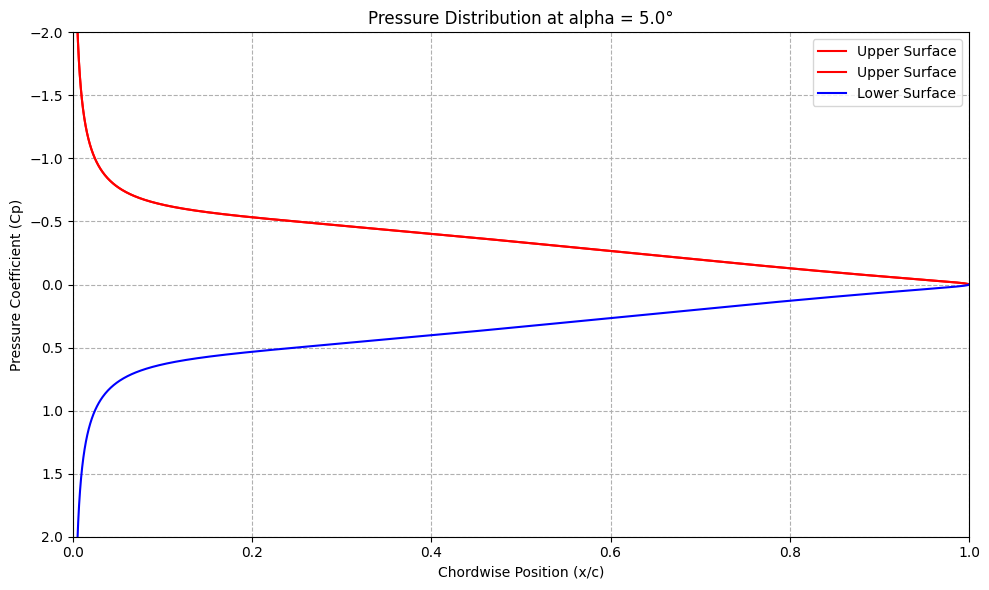

In [7]:
#Bonus 7.1,7.2: Pressure Distribution Calculation and Plotting
from vector_field import calculate_pressure_distribution
from plots import plot_pressure_distribution
cp_upper, cp_lower = calculate_pressure_distribution(U, gamma)

        # Plot pressure and slope for comparison
plot_pressure_distribution(x_v, cp_upper, cp_lower, alpha, x, yc)


In [8]:
check_range = (x_v > 0.10) & (x_v < 0.90)

if np.any(check_range):
    dcp_dx_useful = np.gradient(cp_upper[check_range], x_v[check_range])

    max_adverse = np.max(dcp_dx_useful)
    print(f"Max Adverse Pressure Gradient (excluding LE): {max_adverse:.4f}")
print(f"\n--- Design Diagnostic ---")
print(f"Max Adverse Pressure Gradient: {max_adverse:.4f}")

        # Heuristic threshold: values > 2.0 suggest the camber curvature is too aggressive
if max_adverse > 2.0:
             # Threshold for aggressive design {In reality this limit depends on Reynolds number and other factors, but this is a simple heuristic for demonstration}
            # ALERT: If triggered, go to camber.py to reduce 'm' or smooth the custom_airfoil slope
            print("ALERT: High adverse pressure gradient detected. Consider smoothing the camber slope.")
else:
    
            # SUCCESS: The pressure recovery is gradual, indicating a robust design for this alpha
    print("SUCCESS: Pressure gradient is within stable limits for design alpha.")
            

Max Adverse Pressure Gradient (excluding LE): 1.5780

--- Design Diagnostic ---
Max Adverse Pressure Gradient: 1.5780
SUCCESS: Pressure gradient is within stable limits for design alpha.
